In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [3]:
df = pd.read_csv('/Users/yume/PycharmProjects/PBL2/data/llm_hallucination_dataset_v1.csv')

In [4]:
df.describe()

,hallucination_label,annotation_confidence,notes
count,200.000000,200.000000,0.0
mean,0.345000,0.880650,NaN
std,0.476561,0.063879,NaN
min,0.000000,0.730000,NaN
25%,0.000000,0.830000,NaN
50%,0.000000,0.880000,NaN
75%,1.000000,0.940000,NaN
max,1.000000,0.990000,NaN


In [5]:
df.head()

,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,correction_text,severity,domain_risk,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes
0,70b69889-3b46-4b1e-8f83-b95720bddbcd,2024-11-02,GPT-4o,gpt-4o-2024-11-20,PROMPT_00001,Who invented the telephone?,Multi-Hop,The telephone was invented by Nikola Tesla in ...,History,Question-Answering,...,The telephone was invented by Alexander Graham...,High,Low-Stakes,human_expert,0.73,RAG,True,PubMed,Extrinsic,NaN
1,e93f6574-d3a1-4459-9ccc-8615bc2b627f,2024-09-24,Mistral-Large,mistral-large-2411,PROMPT_00002,What is the boiling point of water at sea level?,Multi-Hop,Water boils at 100 degrees Celsius (212 degree...,Science,Question-Answering,...,NaN,NaN,Low-Stakes,human_expert,0.88,NaN,False,ArXiv,NaN,NaN
2,fc732394-9369-4811-8484-e07f69cb6fab,2025-01-29,Mistral-Large,mistral-large-2411,PROMPT_00003,What is the recommended first-line treatment f...,Ambiguous,The first-line pharmacological treatment for T...,Medicine,Question-Answering,...,Metformin is the recommended first-line pharma...,High,High-Stakes,human_expert,0.83,Self-Consistency,True,SEC-Filing,Extrinsic,NaN
3,2e488a3d-bfc4-4d1e-b59b-eeca571c9c27,2024-10-26,Llama-3.1-70B,llama-3.1-70b-instruct,PROMPT_00004,When was Apple Inc. founded?,Ambiguous,"Apple Inc. was founded on April 1, 1976, by St...",Finance,Question-Answering,...,NaN,NaN,Low-Stakes,human_crowd,0.86,CoT-Prompting,True,PubMed,NaN,NaN
4,eb1c2d1e-9fb6-46f0-9f65-0f36494db9dc,2024-11-07,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00005,Is it legal to record a phone call without con...,Direct-Factual,"In California, you can legally record a phone ...",Law,Fact-Verification,...,California is an all-party consent state; all ...,High,High-Stakes,human_expert,0.95,Structured-Prompt,True,Snopes,Extrinsic,NaN


In [12]:
df_GPT4o= df[df['model_name'] == 'GPT-4o']
df_mistral= df[df['model_name'] == 'Mistral-Large']
df_llama = df[df['model_name'] == 'Llama-3.1-70B']
df_gemini = df[df['model_name'] == 'Gemini-1.5-Pro']

In [11]:
df_GPT4o

,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,correction_text,severity,domain_risk,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes
0,70b69889-3b46-4b1e-8f83-b95720bddbcd,2024-11-02,GPT-4o,gpt-4o-2024-11-20,PROMPT_00001,Who invented the telephone?,Multi-Hop,"The telephone was invented by Nikola Tesla in 1876, who famously demonstrated it at the Centennial Exposition in Philadelphia.",History,Question-Answering,...,The telephone was invented by Alexander Graham Bell in 1876.,High,Low-Stakes,human_expert,0.73,RAG,True,PubMed,Extrinsic,NaN
5,fd4104c5-57f2-4b0e-8c71-1f71f9098231,2025-04-15,GPT-4o,gpt-4o-2024-11-20,PROMPT_00006,What does the acronym 'GPU' stand for?,Ambiguous,GPU stands for Graphics Processing Unit.,Technology,Question-Answering,...,NaN,NaN,Low-Stakes,human_expert,0.90,Structured-Prompt,True,Wikipedia,NaN,NaN
15,8afec273-f83f-4982-9ec2-e225593ba973,2024-12-26,GPT-4o,gpt-4o-2024-11-20,PROMPT_00016,Describe the main capabilities of GPT-5.,Direct-Factual,GPT-5 features a 10-trillion parameter architecture with native video generation capabilities and has been officially certified as AGI-level by OpenAI's safety board in January 2025.,Technology,Open-Generation,...,OpenAI has not officially certified GPT-5 as AGI-level; this claim is fabricated.,High,Medium-Stakes,llm_judge_claude,0.80,CoT-Prompting,True,SEC-Filing,Extrinsic,NaN
18,8d39b8f5-02d6-4891-9eff-d0e32b0b66b8,2024-11-01,GPT-4o,gpt-4o-2024-11-20,PROMPT_00019,My doctor said I might have hypertension. What blood pressure reading is considered hypertension?,Direct-Factual,"Hypertension is generally defined as a blood pressure reading consistently at or above 130/80 mmHg, according to the 2017 ACC/AHA guidelines.",Medicine,Dialogue,...,NaN,NaN,High-Stakes,human_expert,0.98,RAG,True,PubMed,NaN,NaN
22,5249211c-f30c-45e6-bf87-5a77e5afcdc1,2025-01-20,GPT-4o,gpt-4o-2024-11-20,PROMPT_00023,Describe the significance of the Magna Carta.,Multi-Hop,"The Magna Carta, signed in 1215 by King John of England, is considered a foundational document of constitutional governance. It established the principle that the king was subject to the rule of law, guaranteed certain legal rights to free men, and laid groundwork for parliamentary democracy and habeas corpus. The document directly inspired the US Constitution's Bill of Rights in 1791.",History,Open-Generation,...,"While the Magna Carta influenced broader legal traditions, it did not directly inspire the US Bill of Rights, which drew primarily from English common law, state constitutions, and Enlightenment philosophy.",Low,Low-Stakes,human_expert,0.81,Structured-Prompt,True,PubMed,Intrinsic,NaN
23,bcaeaaeb-3e05-4bb3-9e63-ed20fdf8c773,2025-04-09,GPT-4o,gpt-4o-2024-11-20,PROMPT_00024,Does the US Federal Reserve set the federal funds rate?,Ambiguous,"Yes, the Federal Open Market Committee (FOMC), which is part of the Federal Reserve, sets the target range for the federal funds rate.",Finance,Fact-Verification,...,NaN,NaN,Medium-Stakes,llm_judge_gpt4o,0.84,NaN,False,Reuters,NaN,NaN
26,028cbdb7-4e5c-4513-b9ea-108d35c6fc84,2024-09-16,GPT-4o,gpt-4o-2024-11-20,PROMPT_00027,What causes the northern lights?,Adversarial,"The northern lights, or Aurora Borealis, are caused by charged particles from the sun interacting with Earth's magnetic field. These particles travel along magnetic field lines toward the poles, where they collide with gas molecules in the atmosphere, exciting them to emit light in various colors.",Science,Open-Generation,...,NaN,NaN,Low-Stakes,human_expert,0.93,NaN,False,ArXiv,NaN,NaN
28,077687af-44b5-4a9a-94c1-ae96e88d55be,2024-09-26,GPT-4o,gpt-4o-2024-11-20,PROMPT_00029,How many senators are in the US Senate?,Direct-Factual,"The United States Senate has 100 senators, two from each of the 50 states.",Politics,Question-Answering,...,NaN,NaN,Low-Stakes,human_expert,0.88,Structured-P

array([[<Axes: title={'center': 'hallucination_label'}>,
        <Axes: title={'center': 'annotation_confidence'}>],
       [<Axes: title={'center': 'notes'}>, <Axes: >]], dtype=object)

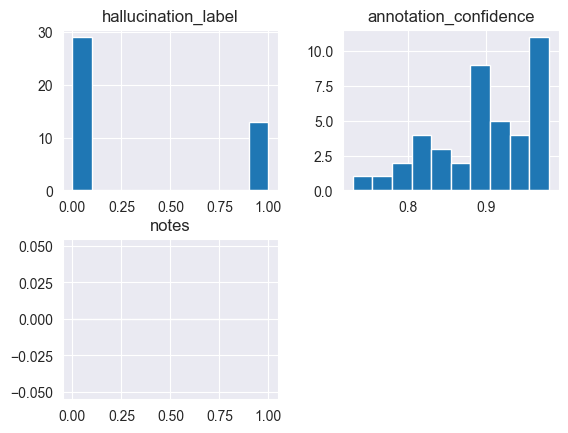

In [10]:
df_GPT4o.hist()

array([[<Axes: title={'center': 'hallucination_label'}>,
        <Axes: title={'center': 'annotation_confidence'}>],
       [<Axes: title={'center': 'notes'}>, <Axes: >]], dtype=object)

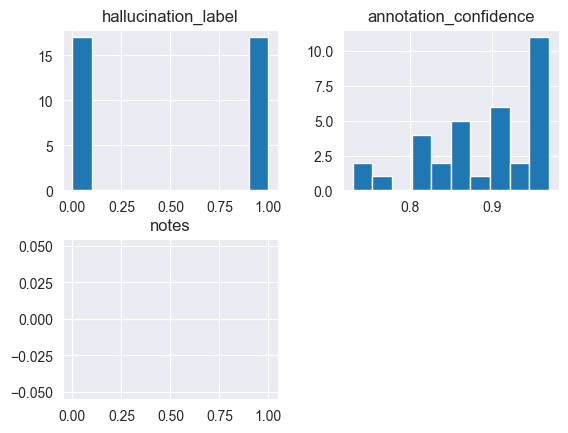

In [13]:
df_gemini.hist()

array([[<Axes: title={'center': 'hallucination_label'}>,
        <Axes: title={'center': 'annotation_confidence'}>],
       [<Axes: title={'center': 'notes'}>, <Axes: >]], dtype=object)

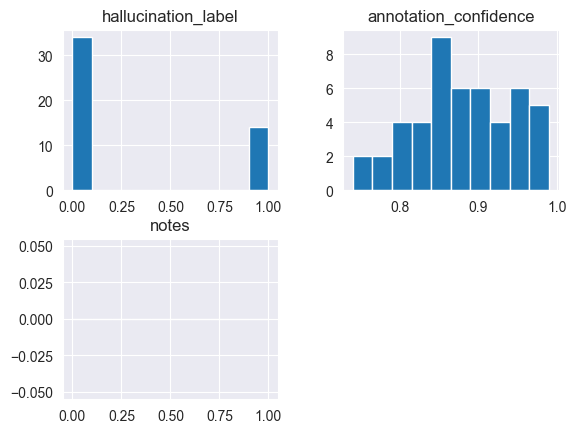

In [14]:
df_llama.hist()

array([[<Axes: title={'center': 'hallucination_label'}>,
        <Axes: title={'center': 'annotation_confidence'}>],
       [<Axes: title={'center': 'notes'}>, <Axes: >]], dtype=object)

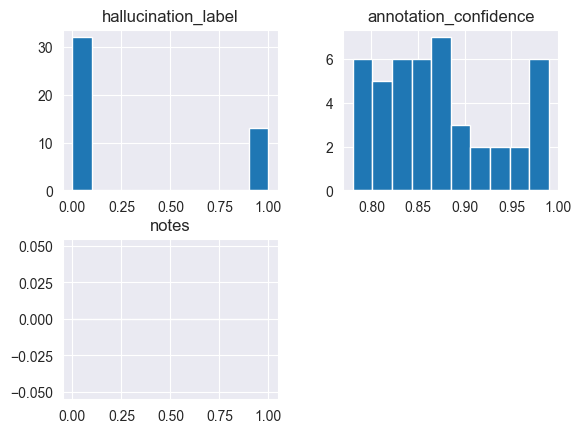

In [15]:
df_mistral.hist()